# M5 Forecasting — California Subset Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import os

# Auto-detect Kaggle vs local
DATA_DIR   = "/kaggle/input/m5-forecasting-accuracy" if os.path.exists("/kaggle/input") else "."
CACHE_FILE = "df_CA_cache.parquet"

if os.path.exists(CACHE_FILE):
    df_CA = pd.read_parquet(CACHE_FILE)
    _from_cache = True
    print(f"Loaded from cache: {df_CA.shape} — skip to Section 4.")
    print(f"Memory: {df_CA.memory_usage(deep=True).sum() / 1e6:.1f} MB")
else:
    _from_cache = False
    print(f"No cache found — will read from {DATA_DIR}")

## 1. Load Sales Data & Extract CA Subset

In [ ]:
if not _from_cache:
    df_sales = pd.read_csv(os.path.join(DATA_DIR, "sales_train_validation.csv"))

    df_sales_CA = df_sales[df_sales["state_id"] == "CA"].copy()
    del df_sales

    id_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
    sales_cols = [col for col in df_sales_CA.columns if col.startswith("d_")]

    df_CA_long = df_sales_CA.melt(
        id_vars=id_cols,
        value_vars=sales_cols,
        var_name="d",
        value_name="sales"
    )
    del df_sales_CA

    df_CA_long["d_num"] = df_CA_long["d"].str.extract(r"d_(\d+)").astype("uint16")

    df_CA_long = df_CA_long.astype({
        "item_id":  "category",
        "dept_id":  "category",
        "cat_id":   "category",
        "store_id": "category",
        "state_id": "category",
        "d":        "category",
        "sales":    "uint16",
    })

    print("CA long shape:", df_CA_long.shape)
    print(f"Memory: {df_CA_long.memory_usage(deep=True).sum() / 1e6:.1f} MB")

## 2. Load Calendar & Merge with CA Data

In [ ]:
if not _from_cache:
    df_calendar = pd.read_csv(os.path.join(DATA_DIR, "calendar.csv"))

    for col in ["event_name_1", "event_type_1", "event_name_2", "event_type_2"]:
        df_calendar[col] = df_calendar[col].fillna("No_Event")

    df_calendar = df_calendar.astype({
        "wm_yr_wk":     "uint16",
        "wday":         "uint8",
        "month":        "uint8",
        "year":         "uint16",
        "weekday":      "category",
        "event_name_1": "category",
        "event_type_1": "category",
        "event_name_2": "category",
        "event_type_2": "category",
        "snap_CA": "bool",
        "snap_TX": "bool",
        "snap_WI": "bool",
    })
    df_calendar["date"] = pd.to_datetime(df_calendar["date"]).astype("datetime64[ms]")

    df_CA_merged = df_CA_long.merge(df_calendar, on="d", how="left")
    del df_calendar

    print("df_CA_merged shape:", df_CA_merged.shape)
    print(f"Memory: {df_CA_merged.memory_usage(deep=True).sum() / 1e6:.1f} MB")

## 3. Load Sell Prices & Merge with CA Data

In [ ]:
if not _from_cache:
    df_sell_prices = pd.read_csv(os.path.join(DATA_DIR, "sell_prices.csv"))

    df_sell_prices_CA = df_sell_prices[df_sell_prices["store_id"].str.startswith("CA")].copy()
    del df_sell_prices

    df_sell_prices_CA = df_sell_prices_CA.astype({
        "store_id":   "category",
        "item_id":    "category",
        "wm_yr_wk":   "uint16",
        "sell_price": "float32",
    })

    df_CA = df_CA_merged.merge(
        df_sell_prices_CA,
        on=["store_id", "item_id", "wm_yr_wk"],
        how="left"
    )
    del df_CA_merged, df_sell_prices_CA

    df_CA.to_parquet(CACHE_FILE, index=False)
    print(f"Cache saved → {CACHE_FILE}")

print("df_CA shape:", df_CA.shape)
print("Stores:", sorted(df_CA["store_id"].unique()))
print(f"Memory: {df_CA.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print("\nNull counts:")
print(df_CA.isnull().sum()[df_CA.isnull().sum() > 0])
df_CA.head()

## 4. Explore df_CA

In [6]:
print(df_CA.dtypes)
print("\nDate range:", df_CA["date"].min(), "→", df_CA["date"].max())
print("d_num range:", df_CA["d_num"].min(), "→", df_CA["d_num"].max())
print(f"Memory: {df_CA.memory_usage(deep=True).sum() / 1e6:.1f} MB")

id                         str
item_id               category
dept_id               category
cat_id                category
store_id              category
state_id              category
d                          str
sales                   uint16
d_num                   uint16
date            datetime64[ms]
wm_yr_wk                uint16
weekday               category
wday                     uint8
month                    uint8
year                    uint16
event_name_1          category
event_type_1          category
event_name_2          category
event_type_2          category
snap_CA                   bool
snap_TX                   bool
snap_WI                   bool
sell_price             float32
dtype: object

Date range: 2011-01-29 00:00:00 → 2016-04-24 00:00:00
d_num range: 1 → 1913
Memory: 2013.3 MB


## Plot 1: Total Daily Sales — California

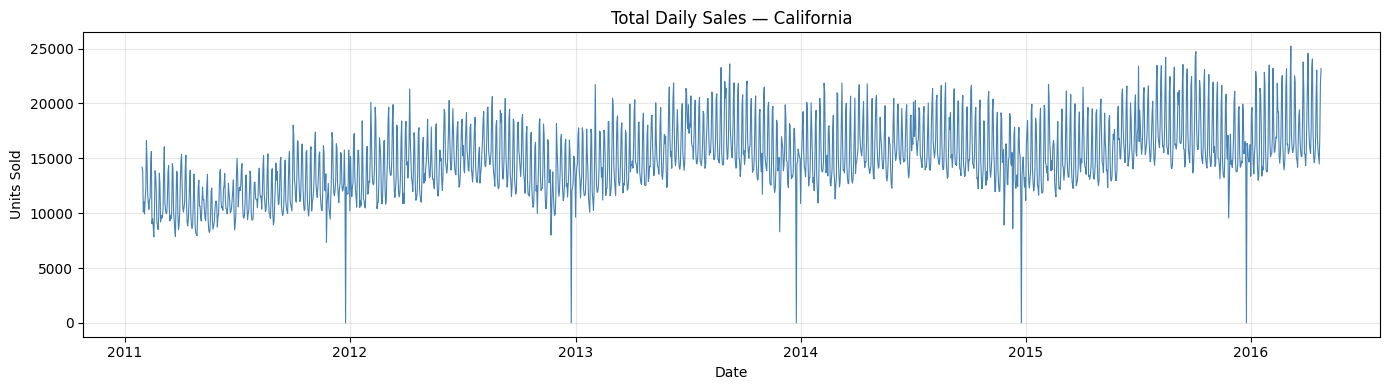

In [7]:
daily_sales = df_CA.groupby("date")["sales"].sum()

plt.figure(figsize=(14, 4))
plt.plot(daily_sales.index, daily_sales.values, linewidth=0.8, color="steelblue")
plt.title("Total Daily Sales — California")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ca_daily_sales.png", dpi=150)
plt.show()

## Plot 2: Daily Sales by CA Store

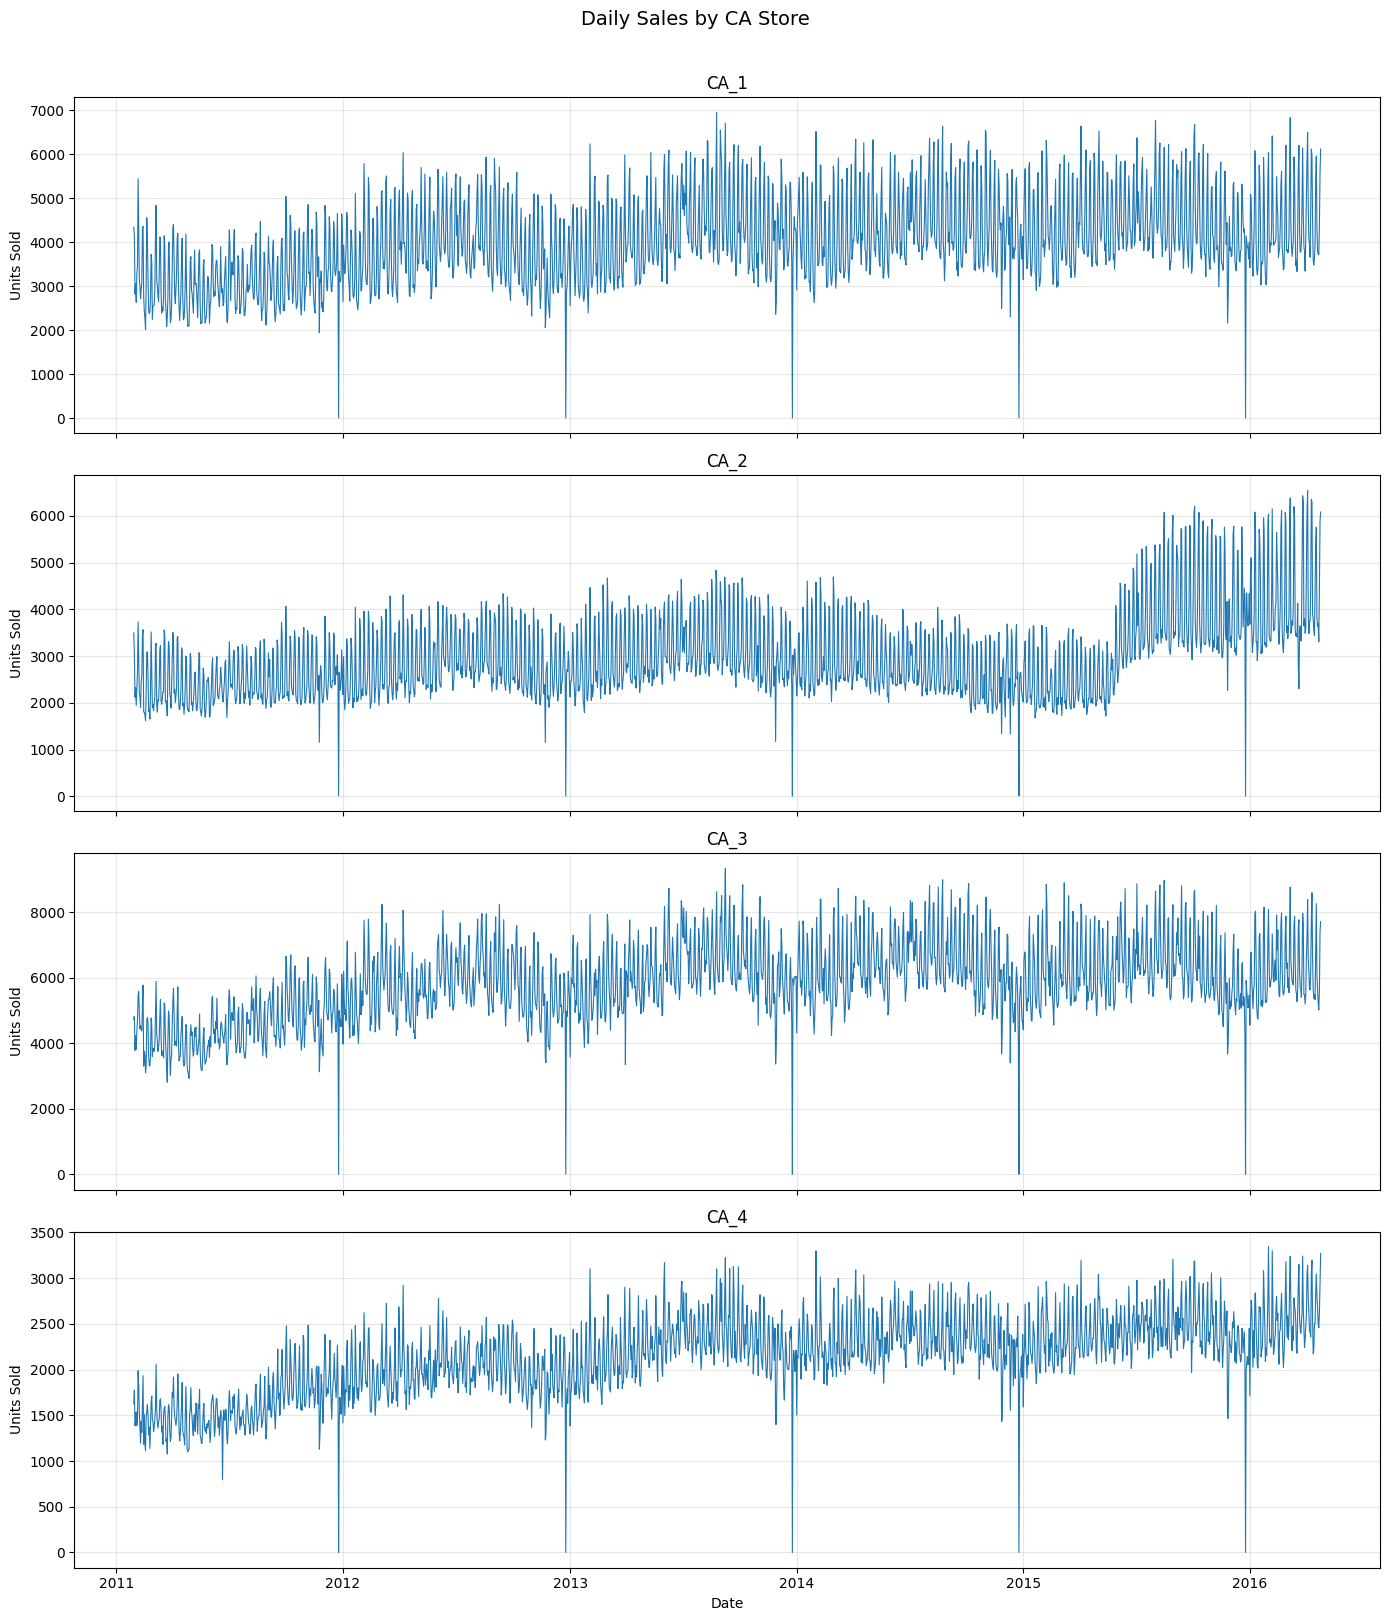

In [8]:
store_daily = df_CA.groupby(["date", "store_id"])["sales"].sum().reset_index()
stores = sorted(df_CA["store_id"].unique())

fig, axes = plt.subplots(len(stores), 1, figsize=(14, 4 * len(stores)), sharex=True)

for ax, store in zip(axes, stores):
    grp = store_daily[store_daily["store_id"] == store]
    ax.plot(grp["date"], grp["sales"], linewidth=0.8)
    ax.set_title(store)
    ax.set_ylabel("Units Sold")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
fig.suptitle("Daily Sales by CA Store", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("ca_sales_by_store.png", dpi=150)
plt.show()

## Plot 3: Daily Sales by Category — California

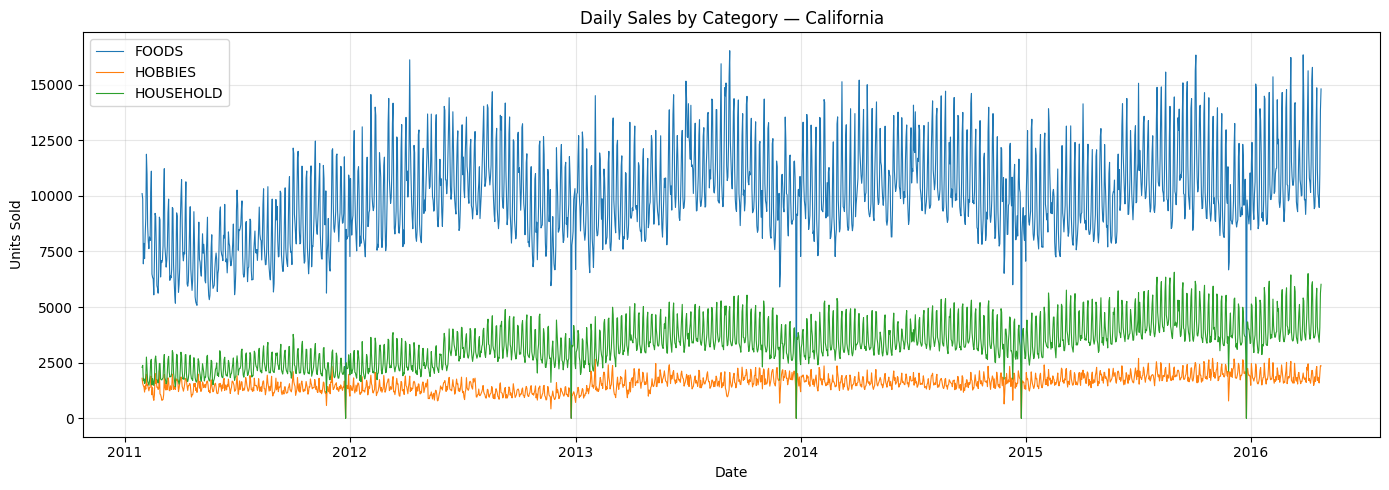

In [9]:
cat_daily = df_CA.groupby(["date", "cat_id"])["sales"].sum().reset_index()

plt.figure(figsize=(14, 5))
for cat, grp in cat_daily.groupby("cat_id"):
    plt.plot(grp["date"], grp["sales"], label=cat, linewidth=0.8)

plt.title("Daily Sales by Category — California")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ca_sales_by_category.png", dpi=150)
plt.show()

## Plot 4: Total Sales by Department — California

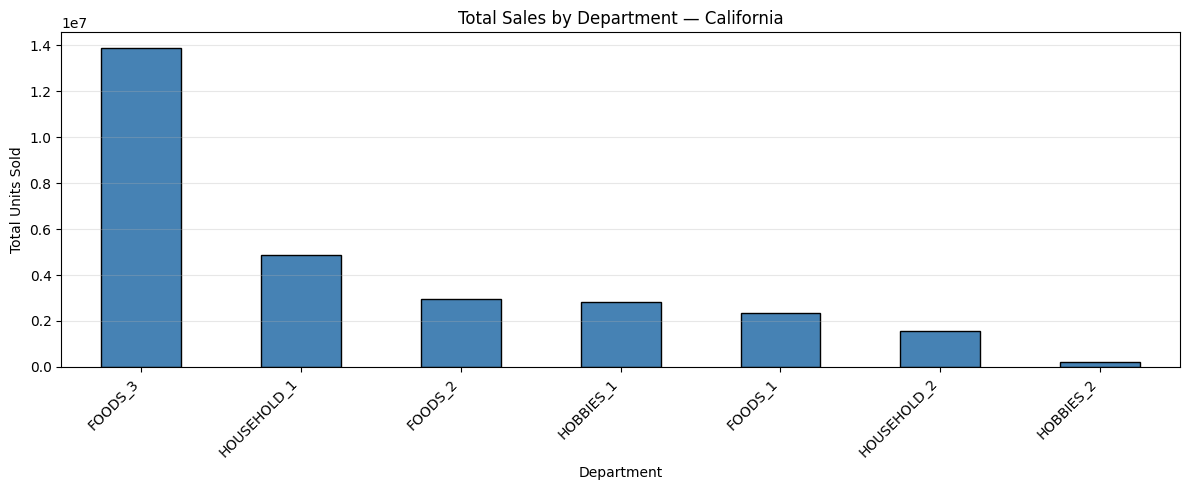

In [10]:
dept_totals = df_CA.groupby("dept_id")["sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
dept_totals.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Total Sales by Department — California")
plt.xlabel("Department")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("ca_sales_by_dept.png", dpi=150)
plt.show()

## Plot 5: SNAP Day Effect on CA Sales

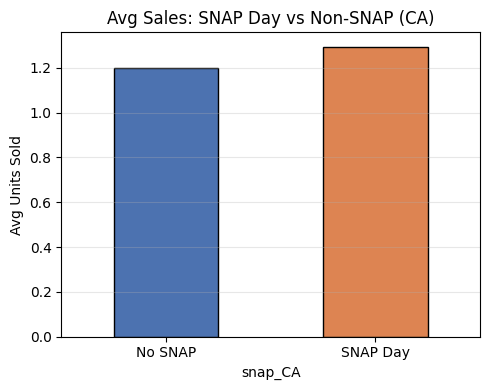

In [11]:
snap_effect = df_CA.groupby("snap_CA")["sales"].mean()

plt.figure(figsize=(5, 4))
snap_effect.plot(kind="bar", color=["#4c72b0", "#dd8452"], edgecolor="black")
plt.title("Avg Sales: SNAP Day vs Non-SNAP (CA)")
plt.ylabel("Avg Units Sold")
plt.xticks([0, 1], ["No SNAP", "SNAP Day"], rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("ca_snap_effect.png", dpi=150)
plt.show()

## Plot 6: Average Sell Price Over Time — California

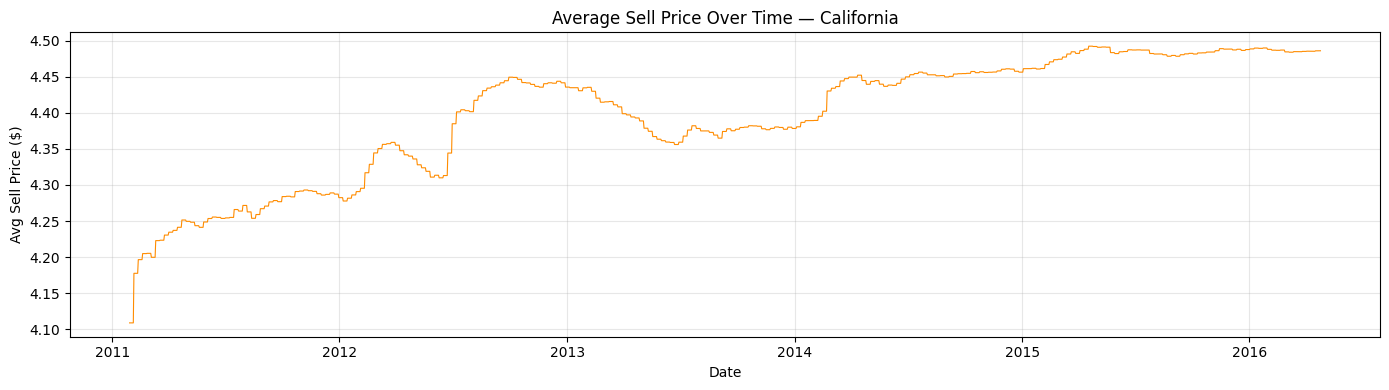

In [12]:
price_trend = df_CA.groupby("date")["sell_price"].mean()

plt.figure(figsize=(14, 4))
plt.plot(price_trend.index, price_trend.values, linewidth=0.8, color="darkorange")
plt.title("Average Sell Price Over Time — California")
plt.xlabel("Date")
plt.ylabel("Avg Sell Price ($)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ca_price_trend.png", dpi=150)
plt.show()

## 7. Stationarity Check (ADF + KPSS)

In [13]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings

sample_series = (
    df_CA.groupby(["cat_id", "item_id", "store_id"], observed=True)["sales"]
    .sum()
    .reset_index()
    .sort_values("sales", ascending=False)
    .drop_duplicates(subset="cat_id")
    .reset_index(drop=True)
)

results = []
for _, row in sample_series.iterrows():
    series = (
        df_CA[
            (df_CA["item_id"] == row["item_id"]) &
            (df_CA["store_id"] == row["store_id"])
        ]
        .sort_values("date")["sales"]
        .values.astype(float)
    )

    adf_stat, adf_p, _, _, _, _ = adfuller(series, autolag="AIC")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_stat, kpss_p, _, _ = kpss(series, regression="c", nlags="auto")

    adf_result  = "Stationary"     if adf_p  < 0.05 else "Non-stationary"
    kpss_result = "Non-stationary" if kpss_p < 0.05 else "Stationary"
    verdict     = adf_result if adf_result == kpss_result else "Conflicting"

    results.append({
        "cat_id": row["cat_id"], "item_id": row["item_id"], "store_id": row["store_id"],
        "ADF p-value": round(adf_p, 4), "ADF result": adf_result,
        "KPSS p-value": round(kpss_p, 4), "KPSS result": kpss_result,
        "Verdict": verdict,
    })

print(pd.DataFrame(results).to_string(index=False))

   cat_id         item_id store_id  ADF p-value     ADF result  KPSS p-value    KPSS result        Verdict
    FOODS     FOODS_3_090     CA_3       0.0007     Stationary          0.01 Non-stationary    Conflicting
HOUSEHOLD HOUSEHOLD_1_118     CA_3       0.0000     Stationary          0.01 Non-stationary    Conflicting
  HOBBIES   HOBBIES_1_234     CA_3       0.1125 Non-stationary          0.01 Non-stationary Non-stationary


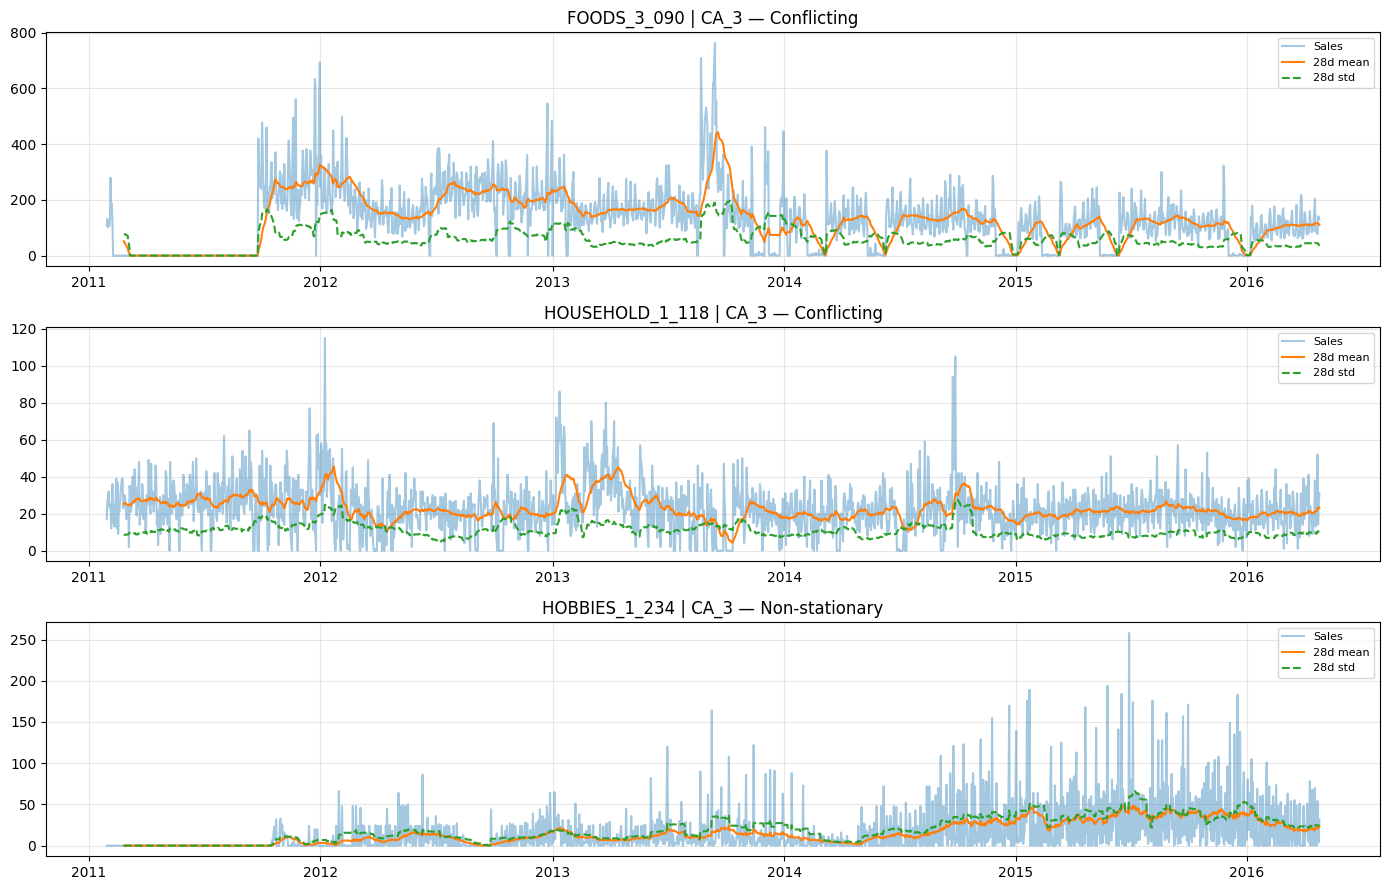

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)

for ax, row in zip(axes, results):
    series = (
        df_CA[
            (df_CA["item_id"] == row["item_id"]) &
            (df_CA["store_id"] == row["store_id"])
        ]
        .sort_values("date")[["date", "sales"]]
        .set_index("date")["sales"]
        .astype(float)
    )
    roll = series.rolling(28)
    ax.plot(series.index, series.values, alpha=0.4, label="Sales")
    ax.plot(roll.mean(), label="28d mean", linewidth=1.5)
    ax.plot(roll.std(),  label="28d std",  linewidth=1.5, linestyle="--")
    ax.set_title(f"{row['item_id']} | {row['store_id']} — {row['Verdict']}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ca_stationarity_rolling.png", dpi=150)
plt.show()

## 7b. Stationarity Check — Stratified by Zero-Rate

In [15]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings

zero_rate = (
    df_CA.groupby(["item_id", "store_id"], observed=True)
    .apply(lambda x: (x["sales"] == 0).mean(), include_groups=False)
    .reset_index(name="zero_rate")
)

zero_rate = zero_rate.merge(
    df_CA[["item_id", "store_id", "cat_id"]].drop_duplicates(),
    on=["item_id", "store_id"]
)

zero_rate["bucket"] = pd.cut(
    zero_rate["zero_rate"],
    bins=[0, 0.5, 1.0],
    labels=["regular", "intermittent"],
    include_lowest=True
)

sample_strat = (
    zero_rate.groupby(["cat_id", "bucket"], observed=True)
    .apply(lambda x: x.sample(n=1, random_state=42))
    .reset_index(level=[0, 1])
    .reset_index(drop=True)
)

print("Sampled series (cat_id x bucket):")
print(sample_strat[["cat_id", "bucket", "item_id", "store_id", "zero_rate"]].to_string(index=False))
print()

def test_stationarity(series):
    adf_stat, adf_p, *_ = adfuller(series, autolag="AIC")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
    adf_result  = "Stationary"     if adf_p  < 0.05 else "Non-stationary"
    kpss_result = "Non-stationary" if kpss_p < 0.05 else "Stationary"
    verdict     = adf_result if adf_result == kpss_result else "Conflicting"
    return pd.Series({"ADF p": round(adf_p, 4), "ADF": adf_result,
                      "KPSS p": round(kpss_p, 4), "KPSS": kpss_result, "Verdict": verdict})

results_strat = []
for _, row in sample_strat.iterrows():
    series = (
        df_CA[(df_CA["item_id"] == row["item_id"]) & (df_CA["store_id"] == row["store_id"])]
        .sort_values("date")["sales"].values.astype(float)
    )
    stats = test_stationarity(series)
    results_strat.append({"cat_id": row["cat_id"], "bucket": row["bucket"],
                           "item_id": row["item_id"], "store_id": row["store_id"],
                           "zero_rate": round(row["zero_rate"], 3), **stats.to_dict()})

print(pd.DataFrame(results_strat).to_string(index=False))

Sampled series (cat_id x bucket):
   cat_id       bucket         item_id store_id  zero_rate
    FOODS      regular     FOODS_3_377     CA_2   0.040774
    FOODS intermittent     FOODS_2_271     CA_3   0.867224
  HOBBIES      regular   HOBBIES_1_194     CA_4   0.448510
  HOBBIES intermittent   HOBBIES_2_066     CA_1   0.920544
HOUSEHOLD      regular HOUSEHOLD_1_204     CA_1   0.270779
HOUSEHOLD intermittent HOUSEHOLD_2_486     CA_1   0.655515

   cat_id       bucket         item_id store_id  zero_rate  ADF p            ADF  KPSS p           KPSS        Verdict
    FOODS      regular     FOODS_3_377     CA_2      0.041 0.0014     Stationary  0.0100 Non-stationary    Conflicting
    FOODS intermittent     FOODS_2_271     CA_3      0.867 0.0663 Non-stationary  0.0100 Non-stationary Non-stationary
  HOBBIES      regular   HOBBIES_1_194     CA_4      0.449 0.0000     Stationary  0.0936     Stationary     Stationary
  HOBBIES intermittent   HOBBIES_2_066     CA_1      0.921 0.0000     Statio

## 7c. Stationarity — Population Estimate with Confidence Intervals

Stratum sizes (population):
cat_id     bucket      
FOODS      regular         1905
           intermittent    3843
HOBBIES    regular          314
           intermittent    1946
HOUSEHOLD  regular          811
           intermittent    3377

Running tests on 180 series...

Stratum                         n  Stationary  Conflicting  Non-stat     Non-stat % (95% CI)  Conclusion
---------------------------------------------------------------------------------------------------------
FOODS/regular                  30           2           26         2    93.3% [78.7%, 98.2%]  Likely Non-stationary
FOODS/intermittent             30           5           13        12    83.3% [66.4%, 92.7%]  Likely Non-stationary
HOBBIES/regular                30           6           20         4    80.0% [62.7%, 90.5%]  Likely Non-stationary
HOBBIES/intermittent           30           5           24         1    83.3% [66.4%, 92.7%]  Likely Non-stationary
HOUSEHOLD/regular              30           4   

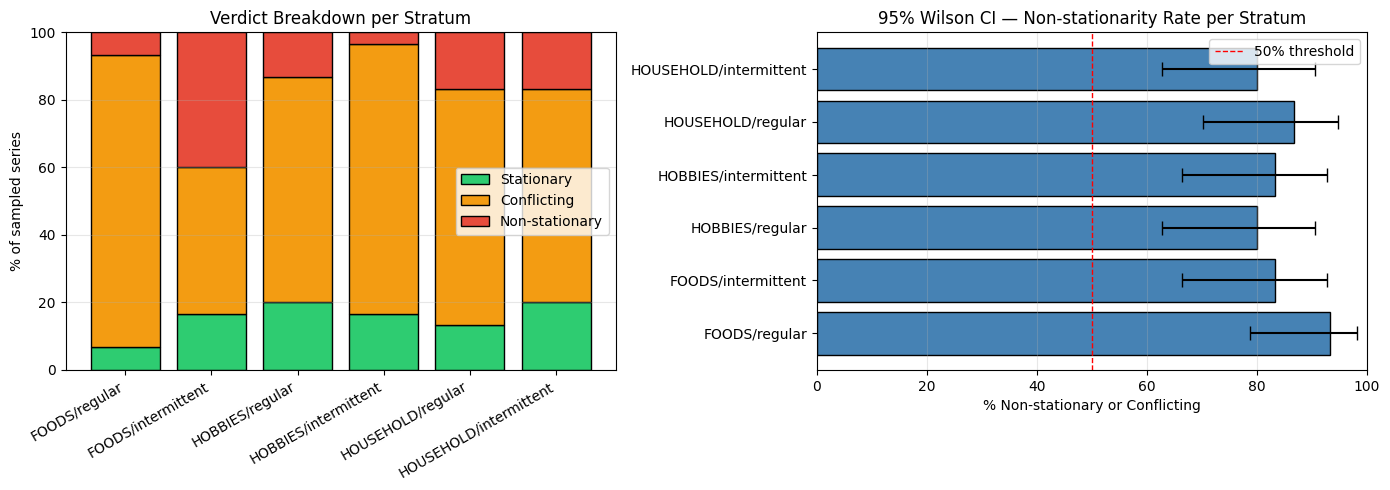

In [16]:
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats
import warnings

SAMPLE_PER_STRATUM = 30

zero_rate_full = (
    df_CA.groupby(["item_id", "store_id"], observed=True)
    .apply(lambda x: (x["sales"] == 0).mean(), include_groups=False)
    .reset_index(name="zero_rate")
    .merge(df_CA[["item_id", "store_id", "cat_id"]].drop_duplicates(), on=["item_id", "store_id"])
)
zero_rate_full["bucket"] = pd.cut(
    zero_rate_full["zero_rate"], bins=[0, 0.5, 1.0],
    labels=["regular", "intermittent"], include_lowest=True
)

print("Stratum sizes (population):")
print(zero_rate_full.groupby(["cat_id", "bucket"], observed=True).size().to_string())
print()

sample = (
    zero_rate_full.groupby(["cat_id", "bucket"], observed=True)
    .apply(lambda x: x.sample(n=min(SAMPLE_PER_STRATUM, len(x)), random_state=42))
    .reset_index(level=[0, 1])
    .reset_index(drop=True)
)

def run_tests(series):
    try:
        _, adf_p, *_ = adfuller(series, autolag="AIC")
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            _, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
        adf_s, kpss_s = adf_p < 0.05, kpss_p >= 0.05
        if adf_s and kpss_s:      return "Stationary"
        elif not adf_s and not kpss_s: return "Non-stationary"
        else:                     return "Conflicting"
    except Exception:
        return None

print(f"Running tests on {len(sample)} series...")
sample["verdict"] = [
    run_tests(
        df_CA[(df_CA["item_id"] == r["item_id"]) & (df_CA["store_id"] == r["store_id"])]
        .sort_values("date")["sales"].values.astype(float)
    )
    for _, r in sample.iterrows()
]
sample = sample[sample["verdict"].notna()].copy()

def wilson_ci(k, n, z=1.96):
    if n == 0: return 0.0, 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = (z * (p * (1 - p) / n + z**2 / (4 * n**2)) ** 0.5) / denom
    return round(p, 3), round(center - margin, 3), round(center + margin, 3)

print(f"\n{'Stratum':<28} {'n':>4}  {'Stationary':>10}  {'Conflicting':>11}  {'Non-stat':>8}  {'Non-stat % (95% CI)':>22}  Conclusion")
print("-" * 105)

ci_rows = []
for (cat, bucket), grp in sample.groupby(["cat_id", "bucket"], observed=True):
    n = len(grp)
    n_s  = (grp["verdict"] == "Stationary").sum()
    n_c  = (grp["verdict"] == "Conflicting").sum()
    n_ns = (grp["verdict"] == "Non-stationary").sum()
    p, lo, hi = wilson_ci(n_ns + n_c, n)
    conclusion = ("Likely Non-stationary" if lo > 0.5 else
                  "Likely Stationary"     if hi < 0.5 else "Uncertain")
    label = f"{cat}/{bucket}"
    print(f"{label:<28} {n:>4}  {n_s:>10}  {n_c:>11}  {n_ns:>8}  {p*100:>6.1f}% [{lo*100:.1f}%, {hi*100:.1f}%]  {conclusion}")
    ci_rows.append({"stratum": label, "p": p, "lo": lo, "hi": hi,
                    "Stationary": n_s, "Conflicting": n_c, "Non-stationary": n_ns, "n": n})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels  = [r["stratum"] for r in ci_rows]
s_vals  = [r["Stationary"]     / r["n"] * 100 for r in ci_rows]
c_vals  = [r["Conflicting"]    / r["n"] * 100 for r in ci_rows]
ns_vals = [r["Non-stationary"] / r["n"] * 100 for r in ci_rows]
x = range(len(labels))

axes[0].bar(x, s_vals,  label="Stationary",     color="#2ecc71", edgecolor="black")
axes[0].bar(x, c_vals,  bottom=s_vals,           label="Conflicting",    color="#f39c12", edgecolor="black")
axes[0].bar(x, ns_vals, bottom=[s+c for s,c in zip(s_vals, c_vals)],
            label="Non-stationary", color="#e74c3c", edgecolor="black")
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(labels, rotation=30, ha="right")
axes[0].set_ylabel("% of sampled series"); axes[0].set_ylim(0, 100)
axes[0].set_title("Verdict Breakdown per Stratum")
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)

ps  = [r["p"] * 100 for r in ci_rows]
los = [r["p"] * 100 - r["lo"] * 100 for r in ci_rows]
his = [r["hi"] * 100 - r["p"] * 100 for r in ci_rows]
axes[1].barh(labels, ps, xerr=[los, his], capsize=5,
             color="steelblue", edgecolor="black", error_kw={"elinewidth": 1.5})
axes[1].axvline(50, color="red", linestyle="--", linewidth=1, label="50% threshold")
axes[1].set_xlabel("% Non-stationary or Conflicting"); axes[1].set_xlim(0, 100)
axes[1].set_title("95% Wilson CI — Non-stationarity Rate per Stratum")
axes[1].legend(); axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("ca_stationarity_ci.png", dpi=150)
plt.show()

## 8. ACF / PACF — Lag Structure

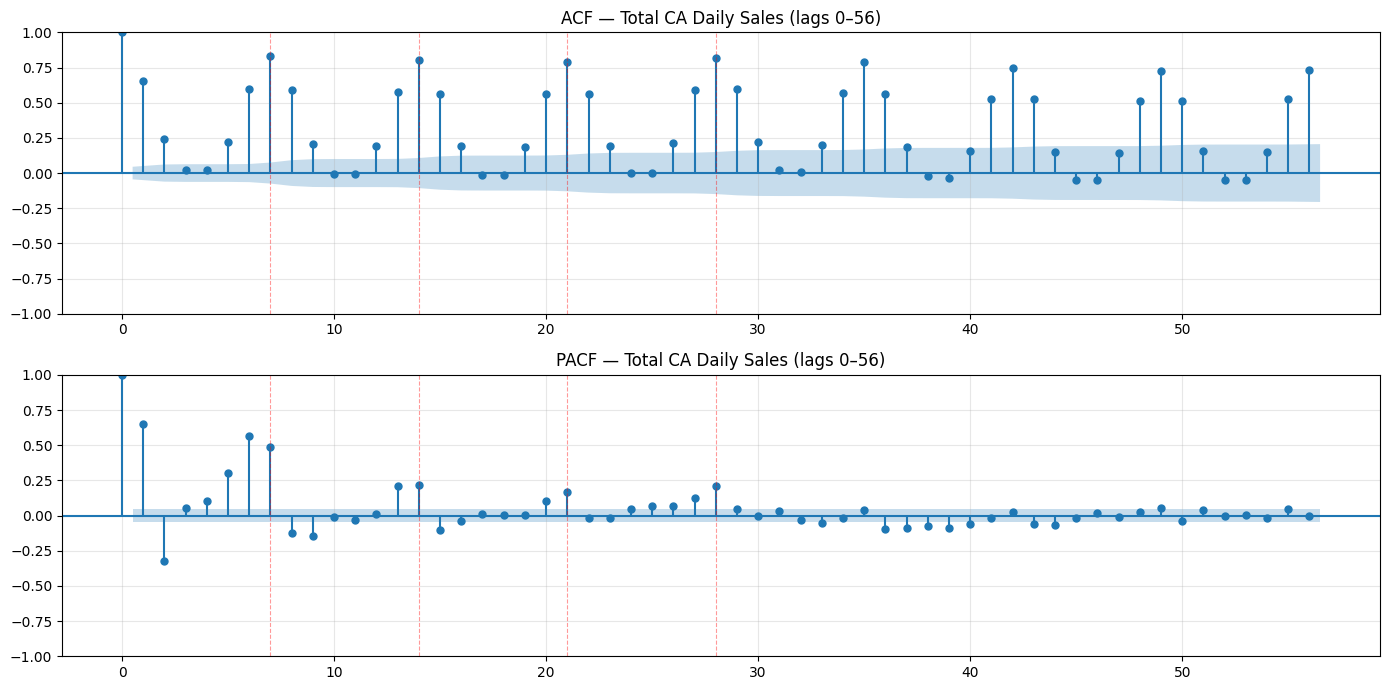

Red dashed lines mark lags 7, 14, 21, 28 — spikes confirm weekly seasonality


In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

agg_series = df_CA.groupby("date", observed=True)["sales"].sum().sort_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
plot_acf(agg_series,  lags=56, ax=axes[0], title="ACF — Total CA Daily Sales (lags 0–56)")
plot_pacf(agg_series, lags=56, ax=axes[1], title="PACF — Total CA Daily Sales (lags 0–56)", method="ywm")

for ax in axes:
    for lag in [7, 14, 21, 28]:
        ax.axvline(lag, color="red", linestyle="--", alpha=0.4, linewidth=0.8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ca_acf_pacf.png", dpi=150)
plt.show()
print("Red dashed lines mark lags 7, 14, 21, 28 — spikes confirm weekly seasonality")

## 9. STL Decomposition — Trend / Seasonality / Residual

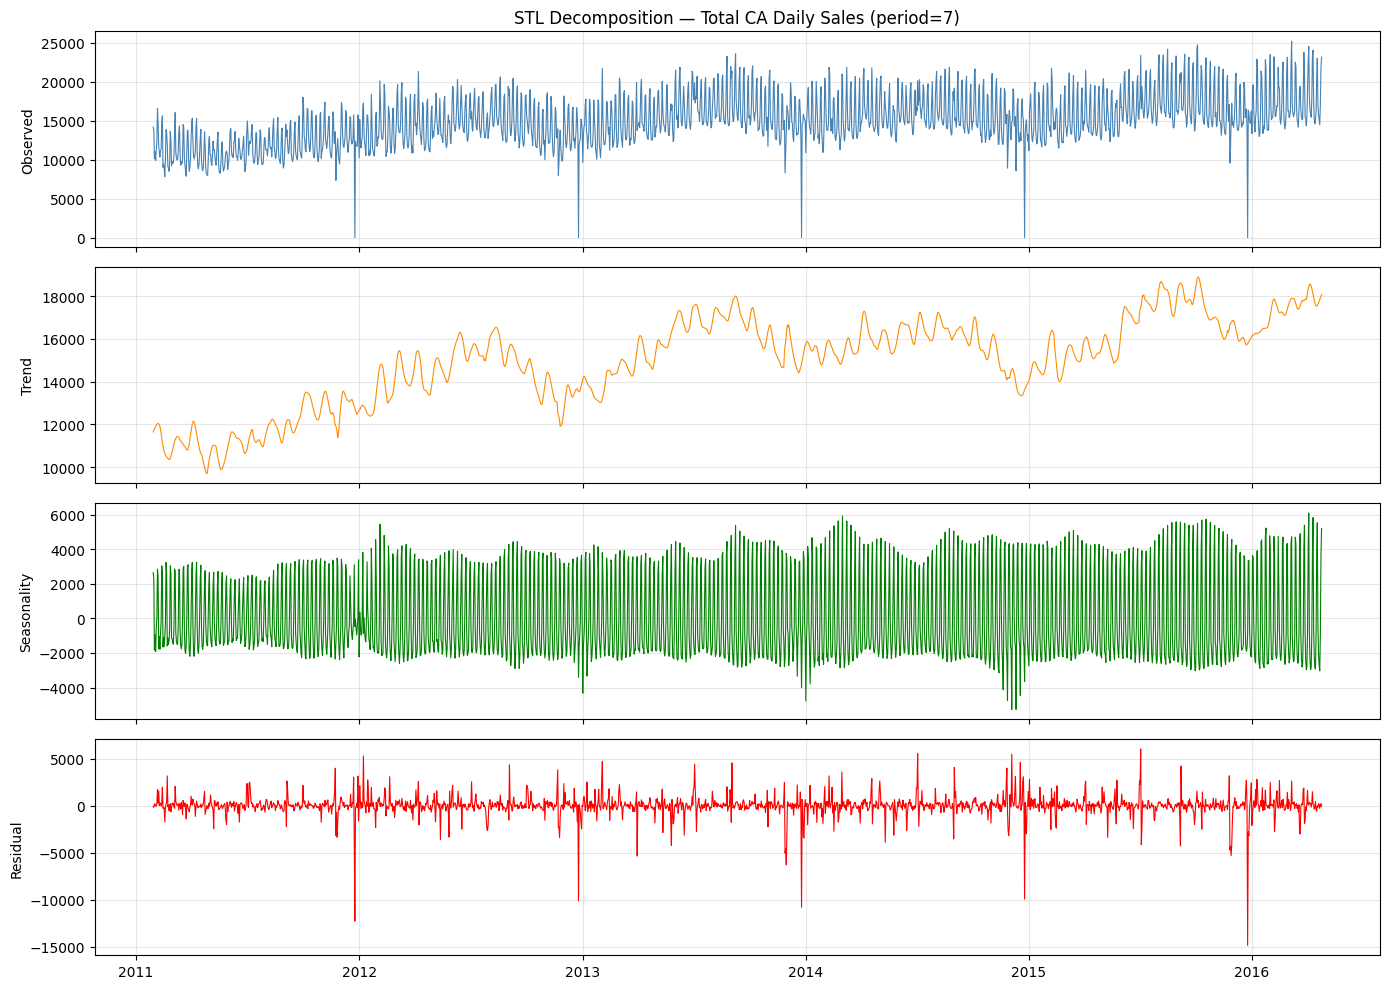

In [18]:
from statsmodels.tsa.seasonal import STL

stl = STL(agg_series, period=7, robust=True)
res = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, (data, label, color) in zip(axes, [
    (agg_series,   "Observed",    "steelblue"),
    (res.trend,    "Trend",       "darkorange"),
    (res.seasonal, "Seasonality", "green"),
    (res.resid,    "Residual",    "red"),
]):
    ax.plot(data, linewidth=0.8, color=color)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)

axes[0].set_title("STL Decomposition — Total CA Daily Sales (period=7)")
plt.tight_layout()
plt.savefig("ca_stl_decomposition.png", dpi=150)
plt.show()

## 10. Day-of-Week Effect

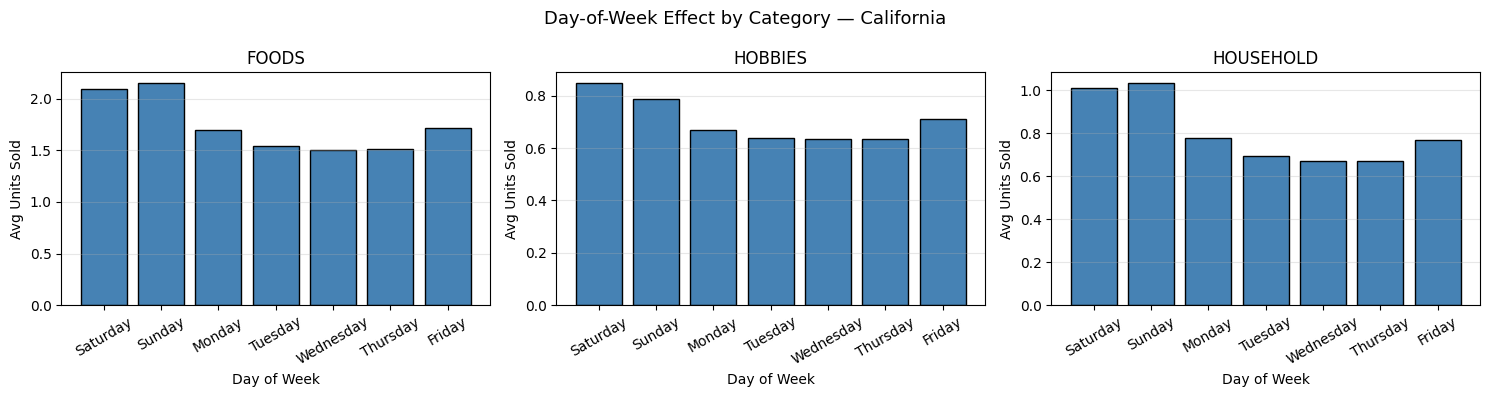

In [19]:
day_order = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]

dow = (
    df_CA.groupby(["weekday", "cat_id"], observed=True)["sales"]
    .mean()
    .reset_index()
)
dow["weekday"] = pd.Categorical(dow["weekday"], categories=day_order, ordered=True)
dow = dow.sort_values("weekday")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, (cat, grp) in zip(axes, dow.groupby("cat_id", observed=True)):
    ax.bar(grp["weekday"], grp["sales"], color="steelblue", edgecolor="black")
    ax.set_title(cat)
    ax.set_xlabel("Day of Week")
    ax.set_ylabel("Avg Units Sold")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Day-of-Week Effect by Category — California", fontsize=13)
plt.tight_layout()
plt.savefig("ca_dow_effect.png", dpi=150)
plt.show()

## 11. Zero-Sales / Intermittency Analysis

Zero-sales rate distribution:
count    12196.000
mean         0.662
std          0.231
min          0.002
25%          0.502
50%          0.710
75%          0.856
max          0.996
Name: zero_rate, dtype: float64
  Series with >50% zero days: 75.2%
  Series with >80% zero days: 35.5%
  Series with >90% zero days: 15.9%


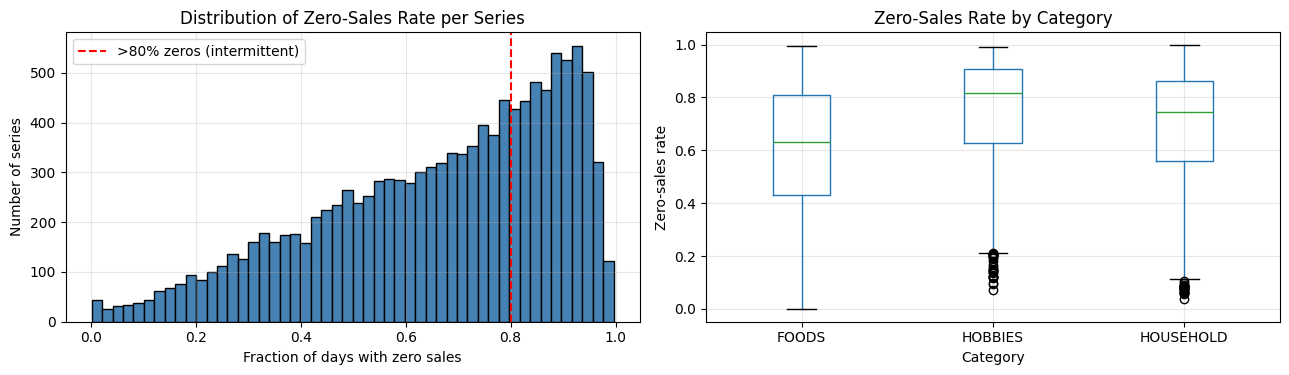

In [20]:
zero_rate = (
    df_CA.groupby(["item_id", "store_id"], observed=True)
    .apply(lambda x: (x["sales"] == 0).mean(), include_groups=False)
    .reset_index(name="zero_rate")
)

print("Zero-sales rate distribution:")
print(zero_rate["zero_rate"].describe().round(3))

for t in [0.5, 0.8, 0.9]:
    pct = (zero_rate["zero_rate"] > t).mean() * 100
    print(f"  Series with >{int(t*100)}% zero days: {pct:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(zero_rate["zero_rate"], bins=50, color="steelblue", edgecolor="black")
axes[0].axvline(0.8, color="red", linestyle="--", label=">80% zeros (intermittent)")
axes[0].set_title("Distribution of Zero-Sales Rate per Series")
axes[0].set_xlabel("Fraction of days with zero sales")
axes[0].set_ylabel("Number of series")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

zero_by_cat = zero_rate.merge(
    df_CA[["item_id", "store_id", "cat_id"]].drop_duplicates(), on=["item_id", "store_id"]
)
zero_by_cat.boxplot(column="zero_rate", by="cat_id", ax=axes[1])
axes[1].set_title("Zero-Sales Rate by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Zero-sales rate")
plt.suptitle("")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ca_zero_sales.png", dpi=150)
plt.show()

## 12. Price Sensitivity

Pearson correlation (sell_price vs sales) by category:
cat_id
FOODS       -0.137
HOBBIES     -0.122
HOUSEHOLD   -0.170
dtype: float64

Price drops >10% in a single week: 5,506 occurrences across 1,470 items


/var/folders/vh/f_5kwmm94wd3wsq5zkx_fwl40000gn/T/ipykernel_95284/2933110004.py:44: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/var/folders/vh/f_5kwmm94wd3wsq5zkx_fwl40000gn/T/ipykernel_95284/2933110004.py:45: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("ca_price_sensitivity.png", dpi=150)
/Users/yamini/miniconda3/envs/ds-env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


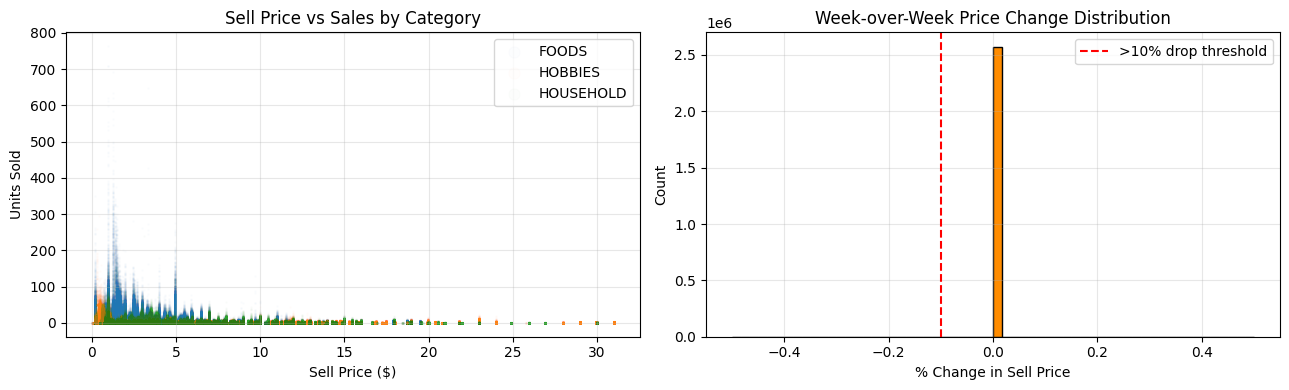

In [21]:
df_priced = df_CA.dropna(subset=["sell_price"])

print("Pearson correlation (sell_price vs sales) by category:")
print(
    df_priced.groupby("cat_id", observed=True)
    .apply(lambda x: x["sell_price"].corr(x["sales"]), include_groups=False)
    .round(3)
)

price_changes = (
    df_CA[["item_id", "store_id", "wm_yr_wk", "sell_price"]]
    .drop_duplicates()
    .sort_values(["item_id", "store_id", "wm_yr_wk"])
)
price_changes["prev_price"] = price_changes.groupby(
    ["item_id", "store_id"], observed=True
)["sell_price"].shift(1)
price_changes["pct_change"] = (
    (price_changes["sell_price"] - price_changes["prev_price"]) / price_changes["prev_price"]
)
big_drops = price_changes[price_changes["pct_change"] < -0.10]
print(f"\nPrice drops >10% in a single week: {len(big_drops):,} occurrences across {big_drops['item_id'].nunique():,} items")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for cat, grp in df_priced.groupby("cat_id", observed=True):
    axes[0].scatter(grp["sell_price"], grp["sales"], alpha=0.01, s=1, label=cat)
axes[0].set_title("Sell Price vs Sales by Category")
axes[0].set_xlabel("Sell Price ($)")
axes[0].set_ylabel("Units Sold")
axes[0].legend(markerscale=8)
axes[0].grid(True, alpha=0.3)

price_changes["pct_change"].dropna().clip(-0.5, 0.5).hist(
    bins=60, ax=axes[1], color="darkorange", edgecolor="black"
)
axes[1].axvline(-0.10, color="red", linestyle="--", label=">10% drop threshold")
axes[1].set_title("Week-over-Week Price Change Distribution")
axes[1].set_xlabel("% Change in Sell Price")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ca_price_sensitivity.png", dpi=150)
plt.show()

## 13. Event Effects by Type

Baseline avg sales (no event): 1.23

Sales lift % on event days by event type and category:
cat_id        FOODS  HOBBIES  HOUSEHOLD
event_type_1                           
Cultural       40.3    -44.1      -36.5
National       25.0    -55.1      -42.2
Religious      37.9    -43.7      -37.6
Sporting       48.6    -44.5      -37.0


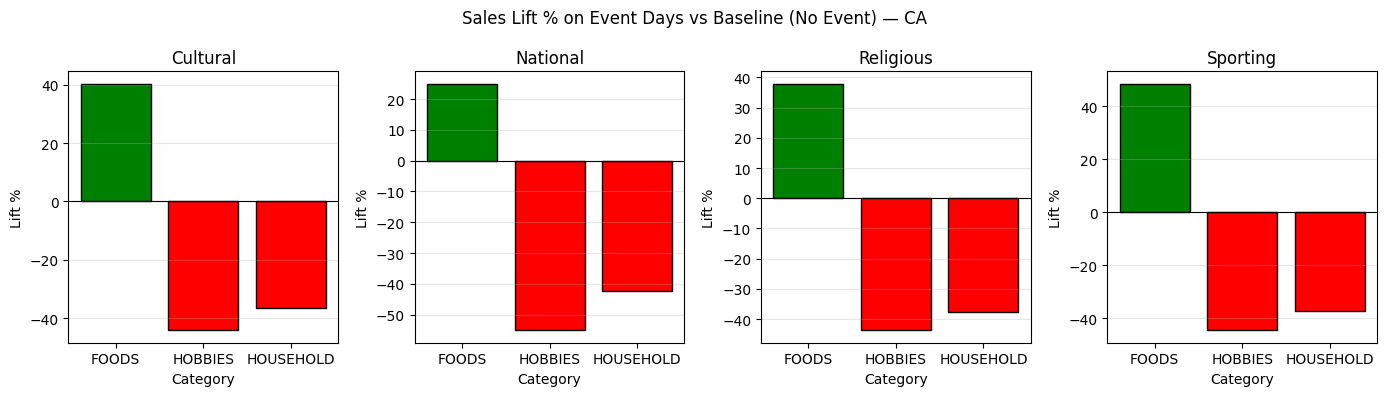

In [22]:
baseline = df_CA[df_CA["event_type_1"] == "No_Event"]["sales"].mean()

event_effect = (
    df_CA[df_CA["event_type_1"] != "No_Event"]
    .groupby(["event_type_1", "cat_id"], observed=True)["sales"]
    .mean()
    .reset_index()
)
event_effect["lift_pct"] = ((event_effect["sales"] - baseline) / baseline * 100).round(1)

print(f"Baseline avg sales (no event): {baseline:.2f}")
print("\nSales lift % on event days by event type and category:")
print(event_effect.pivot(index="event_type_1", columns="cat_id", values="lift_pct").to_string())

event_types = event_effect["event_type_1"].unique()
fig, axes = plt.subplots(1, len(event_types), figsize=(14, 4), sharey=False)

for ax, etype in zip(axes, event_types):
    grp = event_effect[event_effect["event_type_1"] == etype]
    colors = ["green" if v >= 0 else "red" for v in grp["lift_pct"]]
    ax.bar(grp["cat_id"].astype(str), grp["lift_pct"], color=colors, edgecolor="black")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(etype)
    ax.set_xlabel("Category")
    ax.set_ylabel("Lift %")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Sales Lift % on Event Days vs Baseline (No Event) — CA", fontsize=12)
plt.tight_layout()
plt.savefig("ca_event_effects.png", dpi=150)
plt.show()

## 14. Store-Level Correlation

Store-to-store correlation (daily sales):
store_id   CA_1   CA_2   CA_3   CA_4
store_id                            
CA_1      1.000  0.773  0.907  0.851
CA_2      0.773  1.000  0.691  0.696
CA_3      0.907  0.691  1.000  0.874
CA_4      0.851  0.696  0.874  1.000


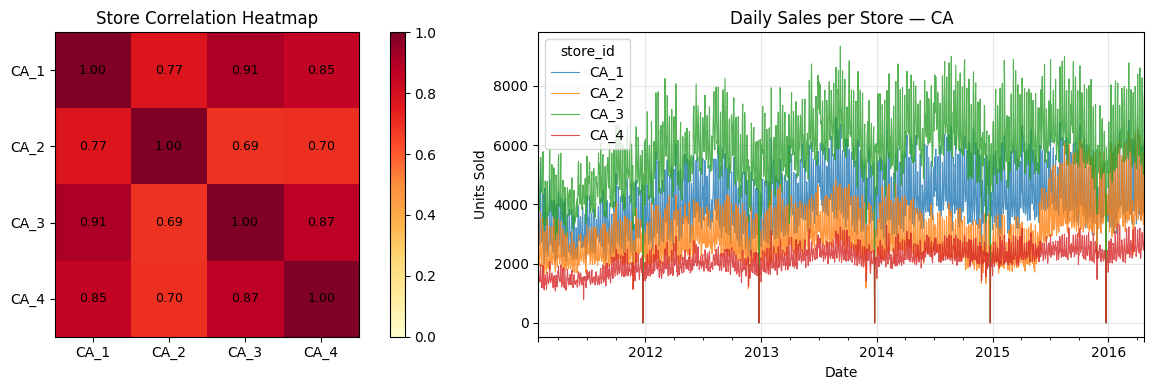

In [23]:
store_daily_pivot = (
    df_CA.groupby(["date", "store_id"], observed=True)["sales"]
    .sum()
    .unstack("store_id")
)

corr = store_daily_pivot.corr()
print("Store-to-store correlation (daily sales):")
print(corr.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

im = axes[0].imshow(corr, vmin=0, vmax=1, cmap="YlOrRd")
axes[0].set_xticks(range(len(corr))); axes[0].set_xticklabels(corr.columns)
axes[0].set_yticks(range(len(corr))); axes[0].set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        axes[0].text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=axes[0])
axes[0].set_title("Store Correlation Heatmap")

store_daily_pivot.plot(ax=axes[1], linewidth=0.8, alpha=0.8)
axes[1].set_title("Daily Sales per Store — CA")
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Units Sold")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ca_store_correlation.png", dpi=150)
plt.show()

## 15. Feature Engineering — Lag Features

In [24]:
import calendar

print("Step 1: Sorting by item_id, store_id, date...")
df_CA = df_CA.sort_values(["item_id", "store_id", "date"]).reset_index(drop=True)
print(f"  Shape: {df_CA.shape}")

print("Step 2a: Computing lag_7 and lag_28...")
grp = df_CA.groupby(["item_id", "store_id"], observed=True)["sales"]
df_CA["lag_7"]  = grp.shift(7).astype("float32")
df_CA["lag_28"] = grp.shift(28).astype("float32")

print("Step 2b: Computing lag_364 (leap-year aware)...")
prev_year     = df_CA["date"].dt.year - 1
lookback_days = prev_year.map(lambda y: 366 if calendar.isleap(y) else 365)
df_CA["_lag_date"] = df_CA["date"] - pd.to_timedelta(lookback_days, unit="D")

lookup = (
    df_CA[["item_id", "store_id", "date", "sales"]]
    .rename(columns={"date": "_lag_date", "sales": "lag_364"})
)
df_CA = df_CA.merge(lookup, on=["item_id", "store_id", "_lag_date"], how="left")
df_CA["lag_364"] = df_CA["lag_364"].astype("float32")
df_CA = df_CA.drop(columns=["_lag_date"])

print(f"Memory: {df_CA.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print("\nNull counts (expected — first N days have no lag):")
print(df_CA[["lag_7", "lag_28", "lag_364"]].isnull().sum())
print("\nSample (one item x store):")
print(
    df_CA[df_CA["item_id"] == df_CA["item_id"].iloc[0]]
    [["date", "sales", "lag_7", "lag_28", "lag_364"]]
    .head(10)
    .to_string(index=False)
)

Step 1: Sorting by item_id, store_id, date...
  Shape: (23330948, 23)
Step 2a: Computing lag_7 and lag_28...
Step 2b: Computing lag_364 (leap-year aware)...
Memory: 2296.3 MB

Null counts (expected — first N days have no lag):
lag_7        85372
lag_28      341488
lag_364    4451540
dtype: int64

Sample (one item x store):
      date  sales  lag_7  lag_28  lag_364
2011-01-29      3    NaN     NaN      NaN
2011-01-30      0    NaN     NaN      NaN
2011-01-31      0    NaN     NaN      NaN
2011-02-01      1    NaN     NaN      NaN
2011-02-02      4    NaN     NaN      NaN
2011-02-03      2    NaN     NaN      NaN
2011-02-04      0    NaN     NaN      NaN
2011-02-05      2    3.0     NaN      NaN
2011-02-06      0    0.0     NaN      NaN
2011-02-07      0    0.0     NaN      NaN
